In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data/fetch_california_housing.csv')
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


| 컬럼명 | 설명 |
| --- | --- |
| MedInc | 해당 지역의 가구 소득 중앙값 (단위: 10,000 달러) |
| HouseAge | 해당 지역 주택의 연식 |
| AveRooms | 가구당 평균 방 개수 |
| AveBedrms | 가구당 평균 침실 개수 |
| Population | 해당 지역의 전체 인구수 |
| AveOccup | 가구당 평균 거주 인원수 |
| Latitude | 해당 지역의 위도 |
| Longitude | 해당 지역의 경도 |
| MedHouseVal | 해당 지역의 주택 가격 중앙값 (단위: 100,000 달러) |

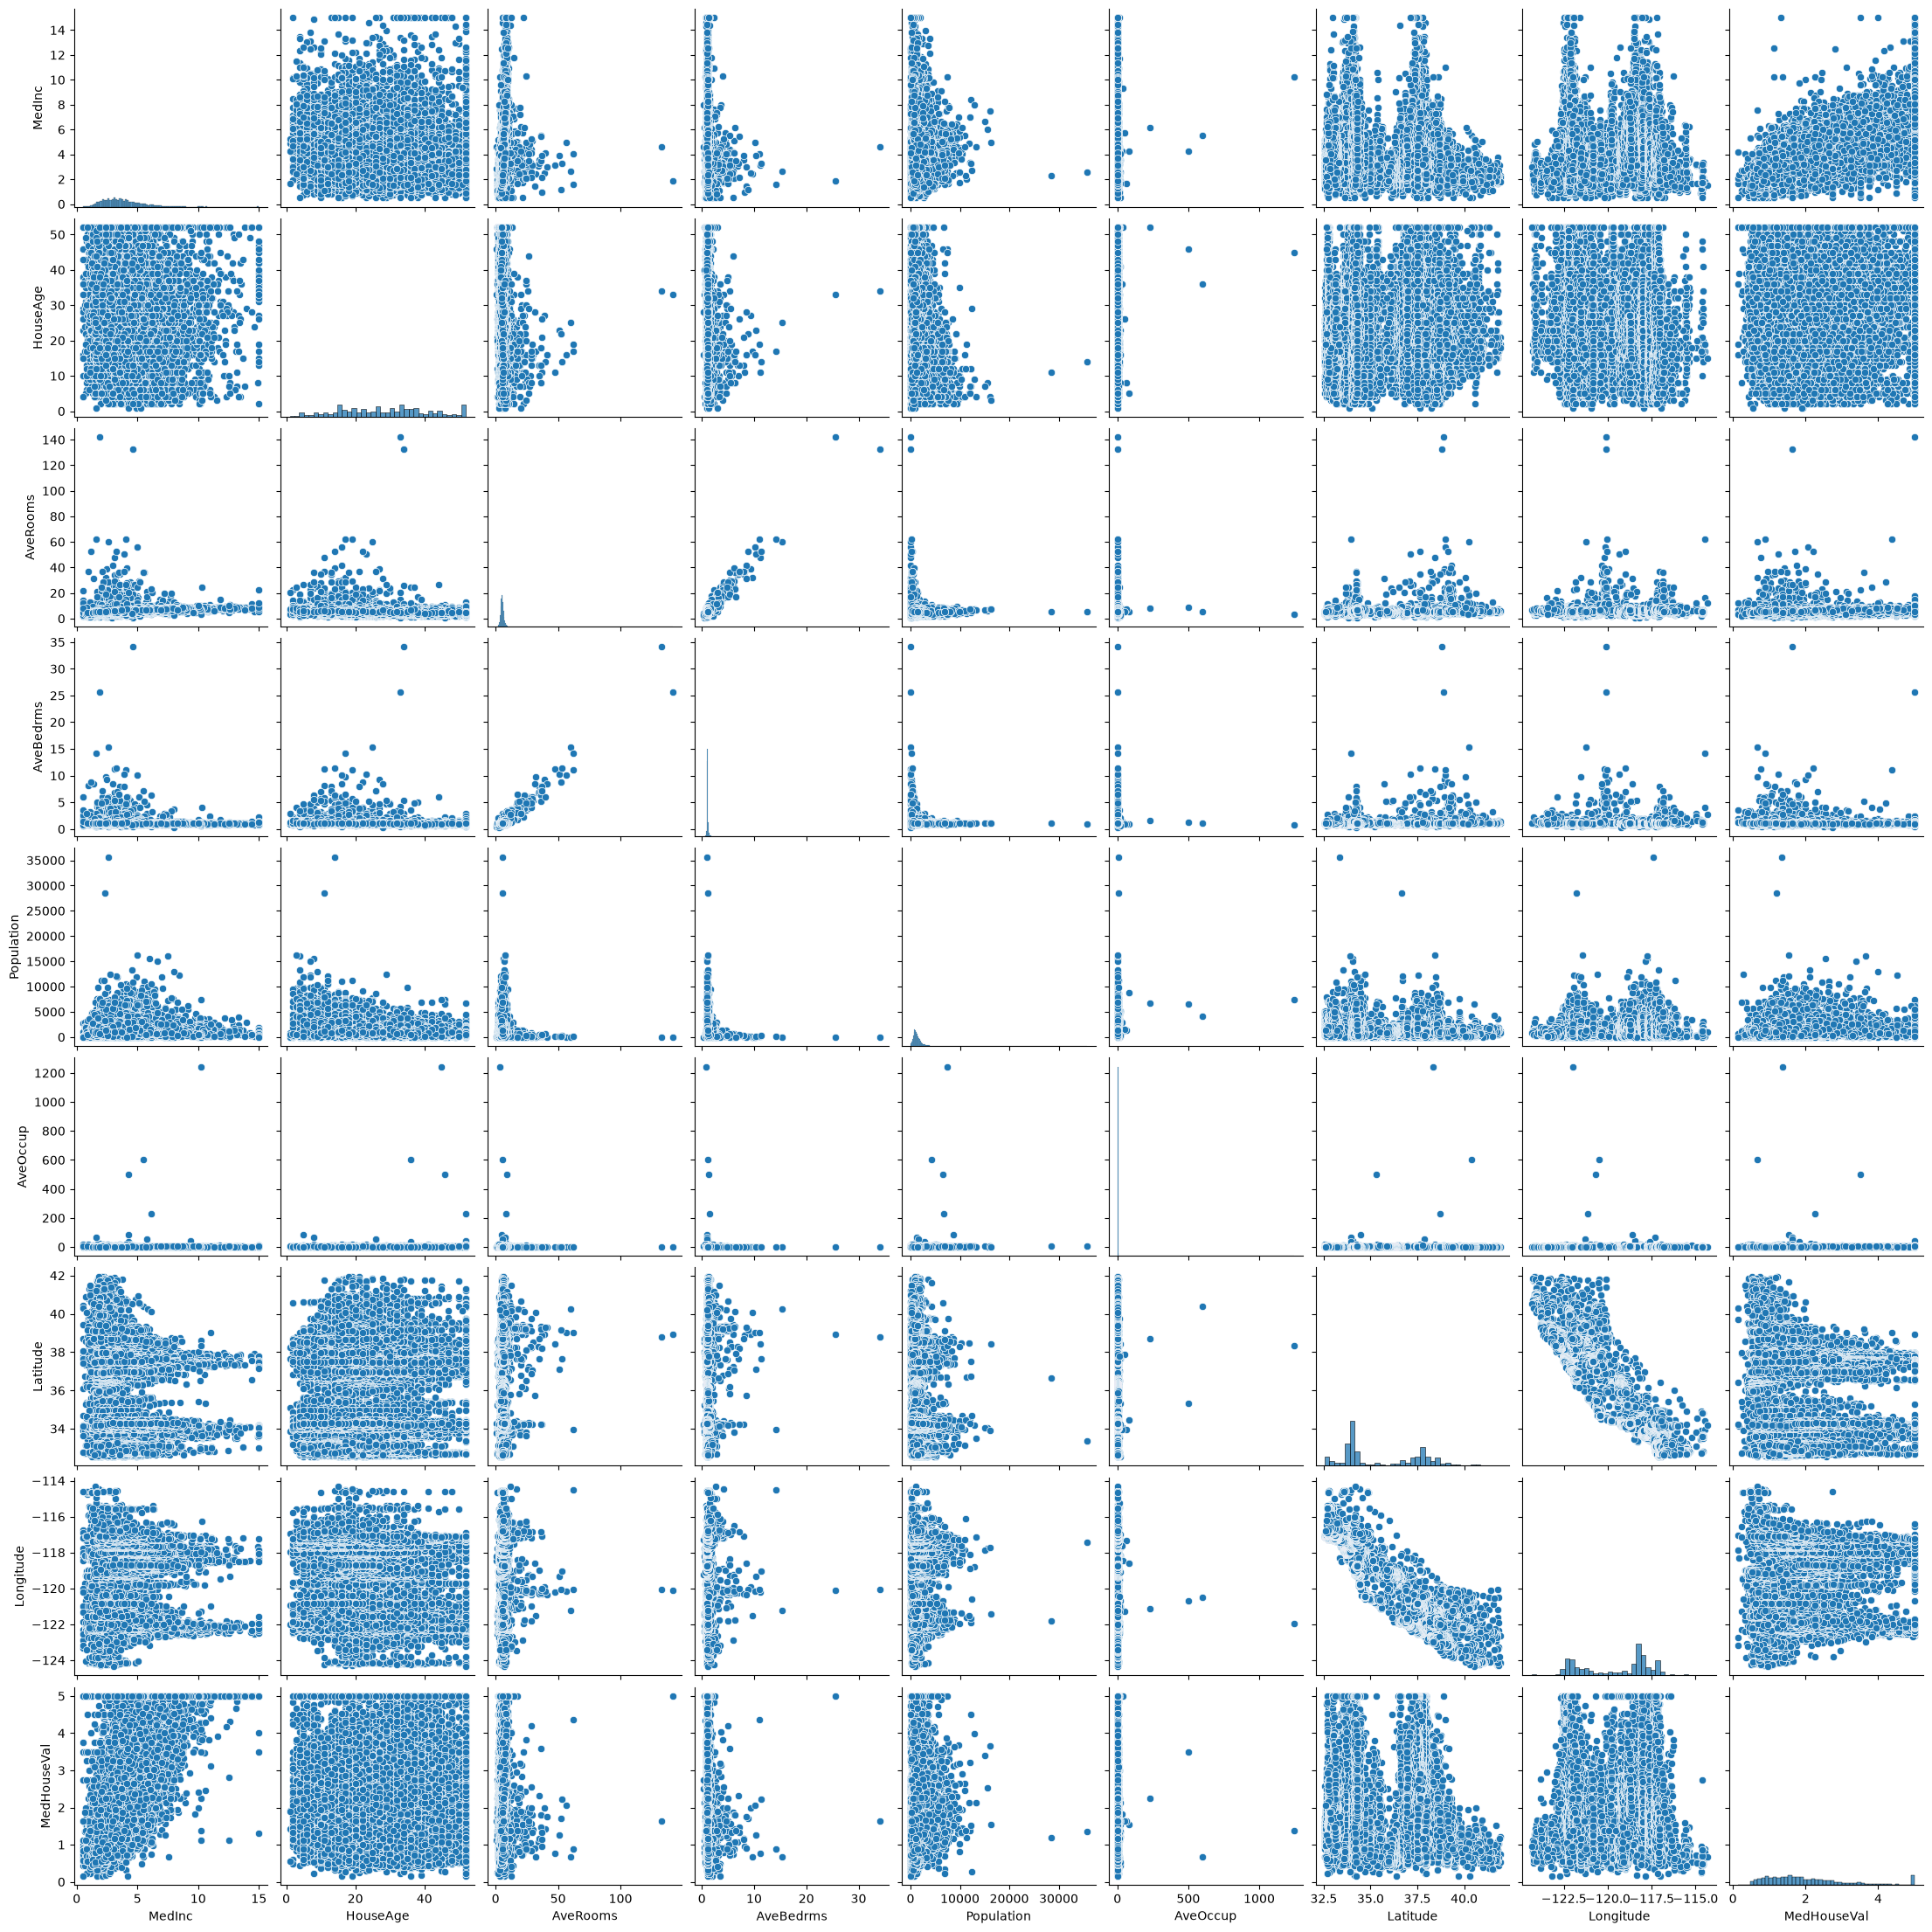

In [4]:
sns.pairplot(df)
plt.show()

In [5]:
import torch                        # 텐서 연산
import torch.nn as nn               # 신경망 모델 구성 (nn.Linear, nn.Sequential)
import torch.nn.functional as F     # 함수형 연산 (F.relu,F.mse_loss)
import torch.optim as optim         # 최적화 알고리즘 (optim.SGD,optim.Adam)

In [6]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [10]:
cols = ['MedHouseVal','MedInc','AveRooms','AveOccup','HouseAge','Population',]

data = torch.from_numpy(df[cols].values).float()    # FloatTensor형태로 변환

data.shape

torch.Size([20640, 6])

In [11]:
# 입력변수 X와 타겟값 y를 분리
X = data[:,1:]
y = data[:,:1]


In [13]:
X.min(dim=0, keepdim=True).values

tensor([[0.4999, 0.8462, 0.6923, 1.0000, 3.0000]])

In [15]:

# X 데이터는 min-max 정규화
x_min = X.min(dim=0, keepdim=True).values
x_max = X.max(dim=0, keepdim=True).values

x = (X-x_min) / (x_max - x_min)
print(x.shape,y.shape)

torch.Size([20640, 5]) torch.Size([20640, 1])


In [16]:
n_epochs =2000          # 학습 반복 횟수
learning_rate = 1e-3    # 학습률 (0.001)
paint_interval = 100    # 손실 출력 간격

In [17]:
model = nn.Linear(x.size(-1),y.size(-1))

model

Linear(in_features=5, out_features=1, bias=True)

In [18]:
# 모델의 파라미터를 자동으로 업데이트하는 최적화 함수
optimizer = optim.SGD(      # 확률적 경사하강법
    model.parameters(),     # 업데이트 할 가중치 및 편향
    lr = learning_rate      # 학습률
)

In [19]:
for i in range(n_epochs):
    y_hat = model(x)        # 순전파

    loss = F.mse_loss(y_hat,y)  # 손실값

    optimizer.zero_grad()   # 가중치 초기화
    loss.backward()         # 역전파

    optimizer.step()        # 파라미터 업데이트

    if (i+1) % paint_interval == 0:
        print(f"Epoch {i+1}의 loss : {loss:.4e}")

Epoch 100의 loss : 4.7172e+00
Epoch 200의 loss : 3.2828e+00
Epoch 300의 loss : 2.4501e+00
Epoch 400의 loss : 1.9659e+00
Epoch 500의 loss : 1.6835e+00
Epoch 600의 loss : 1.5180e+00
Epoch 700의 loss : 1.4202e+00
Epoch 800의 loss : 1.3616e+00
Epoch 900의 loss : 1.3258e+00
Epoch 1000의 loss : 1.3031e+00
Epoch 1100의 loss : 1.2880e+00
Epoch 1200의 loss : 1.2775e+00
Epoch 1300의 loss : 1.2695e+00
Epoch 1400의 loss : 1.2630e+00
Epoch 1500의 loss : 1.2574e+00
Epoch 1600의 loss : 1.2524e+00
Epoch 1700의 loss : 1.2476e+00
Epoch 1800의 loss : 1.2431e+00
Epoch 1900의 loss : 1.2388e+00
Epoch 2000의 loss : 1.2345e+00


torch.cat([y,y_hat],dim=1) : 실제값과 예측값을 열 방향으로 이어붙임  
.detach_().numpy() : 텐서를 계산 그래프에서 분리하고, 넘파이 배열로 변환

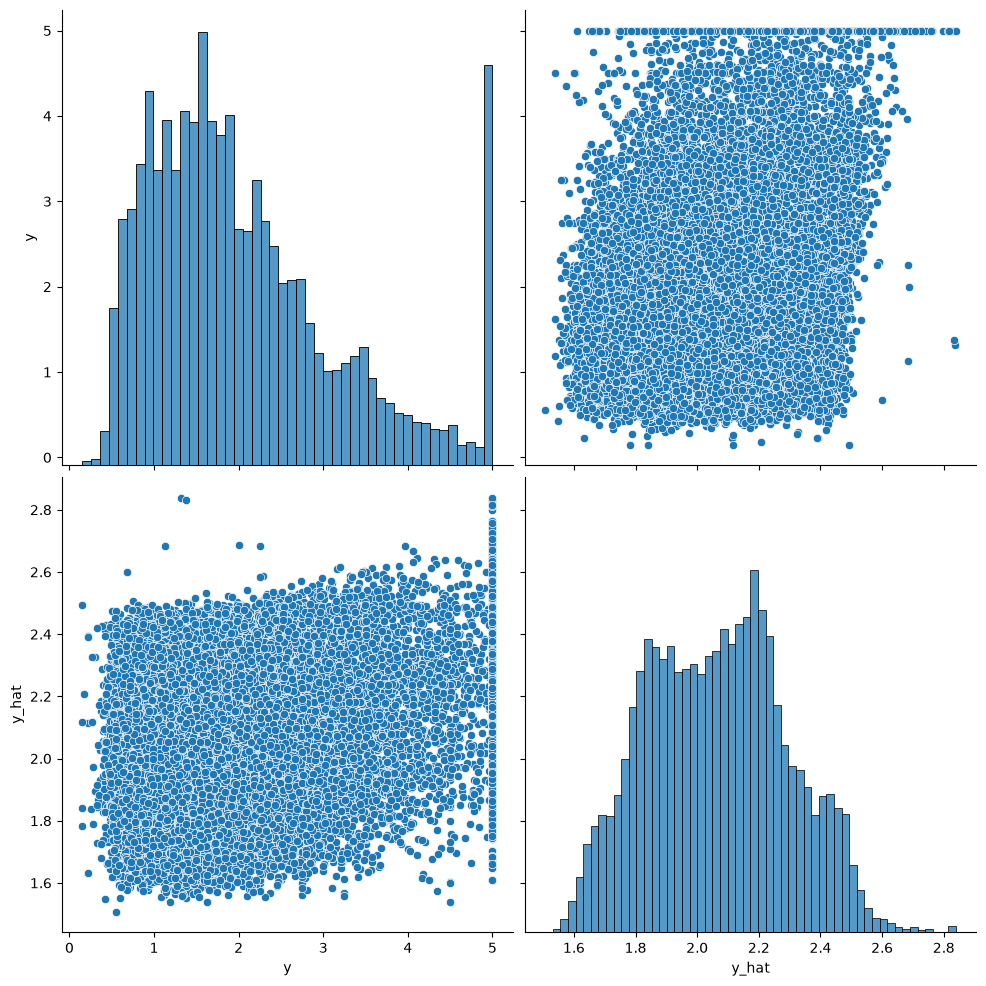

In [20]:
df = pd.DataFrame(
    torch.cat([y,y_hat], dim=1).detach_().numpy(),
    columns=['y','y_hat']
)

sns.pairplot(df,height=5)
plt.show()